# Linear regression with Python

The notebook builds a simple linear regression model that learns a relationship between two input features and a target value. It generates synthetic data from a known linear function, initializes random weights and bias, then uses a forward pass to compute predictions, a mean-squared error loss to measure fit, and gradient descent to update the parameters. The training loop repeatedly computes predictions, loss, gradients, and parameter updates so the model gradually approximates the true linear mapping from features to price.

In [ ]:
# install matplotlib for plotting in the notebook
!pip install matplotlib

In [45]:
import numpy as np  # import numpy for numerical computing
import matplotlib.pyplot as plt  # import plotting functions from matplotlib


# Problem Setup

You can write the relationship with a 2-variable linear equation:


\begin{equation}
y = b + w_1.x_1 + w_2.x_2
\end{equation}

where

$x_i$ → input feature
$w_i$ → weight (what the model learns)
$b$ → bias (offset)
$y$ → target value


In a vector form:


\begin{equation}
y = b + (w_1 w_2).\binom{x_1}{x_2}
\end{equation}


where

\begin{equation}
W = (w_1 w_2)
\end{equation}

and

\begin{equation}
X = \binom{x_1}{x_2}
\end{equation}


# Generating Synthetic Data

In the synthetic data generation step, the function `generate_examples(num=1000)` creates a dataset of 1000 samples by first defining the true underlying relationship with parameters `W = [1.0, -3.0]` and `b = 1.0`. It then generates random input features X (with two variables per sample), typically drawn from a uniform or normal distribution. For each sample, the target value y is computed using the linear equation $y = 1.0 + (1.0x_1) + (-3.0 x_2)$, often with a small amount of random noise added to simulate real-world variability. This process produces a controlled dataset where the correct weights and bias are known in advance, allowing you to verify whether the model can successfully learn and recover these parameters during training.

In [46]:
def generate_examples(num=1000):
    # set true underlying weights and bias
    W = [1.0, -3.0]
    b = 1.0
    
    # reshape W to column vector for matrix multiplication
    W = np.reshape(W, (2,1))
    # sample input features from a standard normal distribution
    X = np.random.randn(num,2)
    
    # compute true targets using linear model y = b + X.W
    y = b + np.dot(X, W)
    
    # reshape output to a column vector
    y = np.reshape(y, (num,1))
    
    return X, y

In [47]:
# generate synthetic training examples using the helper function
X, y = generate_examples()

In [48]:
# display the shapes of the feature matrix and target vector
print(X.shape, y.shape)

(1000, 2) (1000, 1)


In [49]:
# print the first training sample (features and target)
print(X[0], y[0])

[-0.24617375 -0.97254223] [3.67145293]


# Model Initialization

In this step, the `Model` class is created with `num_features=2`, and its parameters are initialized before training begins. Specifically, the weights W are set as a NumPy array with random values (one for each feature, matching the two inputs $x_1$ and $x_2$), and the bias b is initialized to 0 (or a small constant). This means the model starts with no prior knowledge of the true relationship $y = 1.0 + (1.0x_1) + (-3.0 x_2)$, so its initial predictions will be inaccurate. The purpose of this step is to provide a starting point for learning—these random weights and bias will be iteratively adjusted during training via gradient descent until they approximate the true parameters [1.0, -3.0] and 1.0.

The loss over **m** examples:


\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}


The objective of the gradient descent algorithm is to minimize this loss value.

Gradient Descent Objective is to 

\begin{equation}
min(J)
\end{equation}


In [50]:
class Model:
    def __init__(self, num_features):
        # number of features in the input data
        self.num_features = num_features
        # initialize weights randomly for each feature
        self.W = np.random.randn(num_features, 1)
        # initialize bias randomly as a scalar
        self.b = np.random.randn()


In [51]:
# create a model instance with two input features
model = Model(2)
# print the initial random weights and bias
print(model.W)
print(model.b)


[[-0.2651385 ]
 [-1.87979819]]
1.3222353299193599


# Forward Pass (Prediction)

The gradient descent algorithm can be simplified in 4 steps:

1. Get predictions y_hat for X with current values of W and b.
2. Compute the loss between y and y_hat
3. Find gradients of the loss with respect to parameters W and b
4. Update the values of W and b by subtracting the gradient values obtained in the previous step

Let's simplify our linear equation a bit more for an example:

\begin{equation}
y = wx
\end{equation} \tag{7}

The gradients of loss J with respect to w:

\begin{equation}
\frac{dJ}{dw} = \frac{\delta{J}}{\delta{w}} = \lim_{\epsilon \to 0} \frac{J(w + \epsilon) - J(w)}{\epsilon}
\end{equation} \tag{8}

In [52]:
class Model(Model):
    def forward_pass(self, X):
        # compute predicted values using current weights and bias
        y_hat = self.b + np.dot(X, self.W)
        return y_hat


In [53]:
# run a forward pass with a new model instance and print the output shape and sample
y_hat = Model(2).forward_pass(X)
print(y_hat.shape, y_hat[0])


(1000, 1) [-0.06958804]


# Loss Function (How wrong is the model?)

The loss over **m** examples:


\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}

In [54]:
class Model(Model):
    def compute_loss(self, y_hat, y_true):
        # compute mean squared error loss over the batch
        return np.sum(np.square(y_hat - y_true))/(2*y_hat.shape[0])


In [55]:
# create a fresh model instance for loss evaluation
model = Model(2)
# generate predictions using the current random model
y_hat = model.forward_pass(X)
# compute the loss of these predictions against true values
loss = model.compute_loss(y_hat, y)


In [56]:
# display the computed loss value
loss


np.float64(3.6564814007333215)

# Backward Pass (Compute Gradients)

The gradient of loss with respect to bias can be calculated with:

\begin{equation}
\frac{dJ}{db} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y^{(i)}} - y^{(i)})
\end{equation}

\begin{equation}
\frac{dJ}{dW_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y^{(i)}} - y^{(i)}).x_j^{(i)}
\end{equation}

In [57]:
class Model(Model):
    def backward_pass(self, X, y_true, y_hat):
        # number of training examples in the batch
        m = y_true.shape[0]
        # gradient of loss with respect to bias
        db = (1/m)*np.sum(y_hat - y_true)
        # gradient of loss with respect to weights
        dW = (1/m)*np.sum(np.dot(np.transpose(y_hat - y_true), X), axis=0)
        return dW, db


In [58]:
# create a fresh model and compute gradients on the generated data
model = Model(2)
x, y = generate_examples()
y_hat = model.forward_pass(X)
dW, db = model.backward_pass(X, y, y_hat)


Gradients tell which direction reduces error.

In [59]:
# print the computed gradients for weights and bias
print(dW, db)


[-0.787895   -1.65823064] -2.265450165195793


# Update Parameters (Gradient Descent)

In this step, the model improves its predictions by adjusting the weights W and bias b using the gradients computed during the backward pass. Specifically, each parameter is updated using the rules `W = W - lr * dW` and `b = b - lr * db`, where `lr` is the learning rate (a small positive value controlling step size), and `dW` and `db` represent how much each parameter contributed to the prediction error. The subtraction means the model moves in the opposite direction of the gradient, which is the direction that reduces the loss. Over many iterations, these incremental updates gradually shift the parameters from their initial random values toward the true values [1.0, -3.0] and 1.0, minimizing the error between predicted and actual outputs.

In [60]:
class Model(Model):
    def update_params(self, dW, db, lr):
        # update weights using gradient descent step
        self.W = self.W - lr * np.reshape(dW, (self.num_features, 1))
        # update bias using gradient descent step
        self.b = self.b - db


# Training Loop

Each iteration does:

1. Forward pass → predictions
2. Compute loss
3. Backward pass → gradients
4. Update parameters

In [61]:
class Model(Model):
    def train(self, X_train, y_train, iterations, lr):
        # collect loss values over training iterations
        losses = []
        for i in range(0, iterations):
            # compute predictions for the current batch
            y_hat = self.forward_pass(X_train)
            # compute current loss
            loss = self.compute_loss(y_hat, y_train)
            # compute gradients with respect to parameters
            dW, db = self.backward_pass(X_train, y_train, y_hat)
            # update parameters using the gradients
            self.update_params(dW, db, lr)
            losses.append(loss)
            if i % int(iterations/10) == 0:
                print(f"Iteration: {i}, Loss: {loss:4f}")
        return losses


In [62]:
# create a new model instance for training
model = Model(2)


In [63]:
# generate training data for the model
X_train, y_train = generate_examples()


In [64]:
# train the model for 1000 iterations with a small learning rate
losses = model.train(X_train, y_train, 1000, 3e-3)


Iteration: 0, Loss: 2.857052
Iteration: 100, Loss: 1.057511
Iteration: 200, Loss: 0.561202
Iteration: 300, Loss: 0.297825
Iteration: 400, Loss: 0.158056
Iteration: 500, Loss: 0.083882
Iteration: 600, Loss: 0.044518
Iteration: 700, Loss: 0.023627
Iteration: 800, Loss: 0.012540
Iteration: 900, Loss: 0.006656


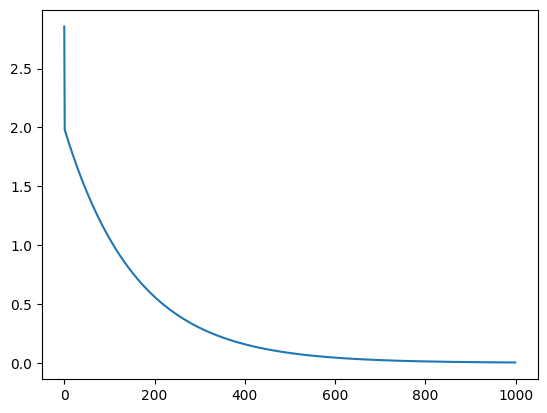

In [65]:
# plot the training loss curve to observe convergence
plt.plot(losses)


# Predictions

In [66]:
# create an untrained model to compare against the trained one
model_untrained = Model(2)

# generate a new test dataset
X_test, y_test = generate_examples(500)
print(X_test.shape, y_test.shape)


(500, 2) (500, 1)


In [67]:
# compute predictions from both the untrained and trained models
preds_untrained = model_untrained.forward_pass(X_test)
preds_trained = model.forward_pass(X_test)


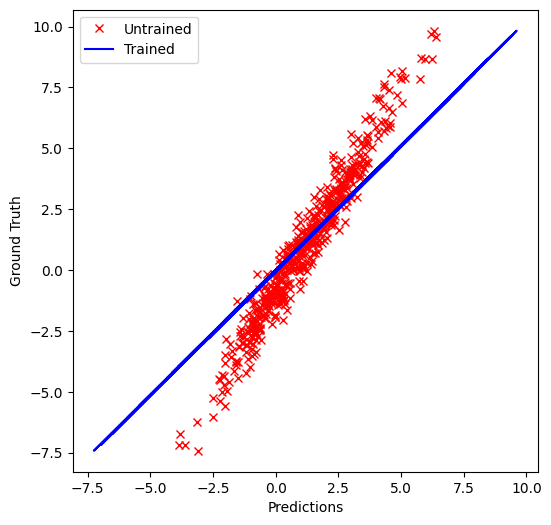

In [68]:
# plot predicted values against true targets for both models
plt.figure(figsize=(6, 6))
plt.plot(preds_untrained, y_test, 'rx', label='Untrained')
plt.plot(preds_trained, y_test, 'b', label='Trained')
plt.legend()
plt.xlabel('Predictions')
plt.ylabel('Ground Truth')
plt.show()
